<h1><font color="blue">정렬&순위 그리고 누락 값</font></h1>

<h2><font color="red">데이터 정렬하기</font></h2>

<h4><font color="green">데이터 프레임 읽기</font></h4>

In [1]:
import pandas as pd

In [2]:
payment = pd.read_csv('./../data/payment01.csv', encoding='CP949', \
                      index_col='사원명')
payment

,출장지역,출장기간,부서,성별,교통비,식비
사원명,,,,,,
강미림,서울,3.0,영업부,남자,1000.0,500
장도윤,서울,NaN,총무부,남자,2000.0,300
김상민,부산,7.0,전산부,남자,3000.0,600
신승현,부산,5.0,영업부,여자,NaN,200
선우재민,서울,6.0,총무부,여자,4000.0,800


<h6><font color="BlueViolet">출장 기간 열을 Series로 추출</font></h6>

In [3]:
period = payment['출장기간']
period.to_frame().T

사원명,강미림,장도윤,김상민,신승현,선우재민
출장기간,3.0,NaN,7.0,5.0,6.0


<h6><font color="BlueViolet">색인을 이용한 정렬</font></h6>

In [4]:
result = period.sort_index()
result.to_frame()

,출장기간
사원명,
강미림,3.0
김상민,7.0
선우재민,6.0
신승현,5.0
장도윤,NaN


In [5]:
result = period.sort_index(ascending=False)
result.to_frame()

,출장기간
사원명,
장도윤,NaN
신승현,5.0
선우재민,6.0
김상민,7.0
강미림,3.0


<h6><font color="BlueViolet">값을 이용한 정렬</font></h6>

In [6]:
result = period.sort_values()
result.to_frame()

,출장기간
사원명,
강미림,3.0
신승현,5.0
선우재민,6.0
김상민,7.0
장도윤,NaN


In [7]:
result = period.sort_values(ascending=False)
result.to_frame()

,출장기간
사원명,
김상민,7.0
선우재민,6.0
신승현,5.0
강미림,3.0
장도윤,NaN


<h4><font color="green">axis 옵션을 이용한 DataFrame 정렬하기</font></h4>

<h6><font color="BlueViolet">오름차순 정렬하기</font></h6>

In [8]:
result = payment.sort_index(axis = 0)
result

,출장지역,출장기간,부서,성별,교통비,식비
사원명,,,,,,
강미림,서울,3.0,영업부,남자,1000.0,500
김상민,부산,7.0,전산부,남자,3000.0,600
선우재민,서울,6.0,총무부,여자,4000.0,800
신승현,부산,5.0,영업부,여자,NaN,200
장도윤,서울,NaN,총무부,남자,2000.0,300


In [9]:
result = payment.sort_index(axis = 1)
result

,교통비,부서,성별,식비,출장기간,출장지역
사원명,,,,,,
강미림,1000.0,영업부,남자,500,3.0,서울
장도윤,2000.0,총무부,남자,300,NaN,서울
김상민,3000.0,전산부,남자,600,7.0,부산
신승현,NaN,영업부,여자,200,5.0,부산
선우재민,4000.0,총무부,여자,800,6.0,서울


<h6><font color="BlueViolet">내림차순 정렬하기</font></h6>

In [10]:
result = payment.sort_index(axis=1, ascending=False)
result

,출장지역,출장기간,식비,성별,부서,교통비
사원명,,,,,,
강미림,서울,3.0,500,남자,영업부,1000.0
장도윤,서울,NaN,300,남자,총무부,2000.0
김상민,부산,7.0,600,남자,전산부,3000.0
신승현,부산,5.0,200,여자,영업부,NaN
선우재민,서울,6.0,800,여자,총무부,4000.0


<h4><font color="green">값을 이용한 DataFrame 정렬하기</font></h4>

<h6><font color="BlueViolet">by 매개 변수 사용</font></h6>

In [11]:
# 교통비가 적은 컬럼 부터 조회하세요.
result = payment.sort_values(by=['교통비'])
result

,출장지역,출장기간,부서,성별,교통비,식비
사원명,,,,,,
강미림,서울,3.0,영업부,남자,1000.0,500
장도윤,서울,NaN,총무부,남자,2000.0,300
김상민,부산,7.0,전산부,남자,3000.0,600
선우재민,서울,6.0,총무부,여자,4000.0,800
신승현,부산,5.0,영업부,여자,NaN,200


<h6><font color="BlueViolet">ascending 매개 변수 사용 </font></h6>

In [12]:
# 교통비가 많은 컬럼 부터 조회하세요.
result = payment.sort_values(by=['교통비'], ascending=[False])
result

,출장지역,출장기간,부서,성별,교통비,식비
사원명,,,,,,
선우재민,서울,6.0,총무부,여자,4000.0,800
김상민,부산,7.0,전산부,남자,3000.0,600
장도윤,서울,NaN,총무부,남자,2000.0,300
강미림,서울,3.0,영업부,남자,1000.0,500
신승현,부산,5.0,영업부,여자,NaN,200


<h6><font color="BlueViolet">여러 개의 컬럼 명시하기</font></h6>

In [13]:
result = payment.sort_values(by=['출장지역', '교통비'], \
                             ascending=[True, False])
result

,출장지역,출장기간,부서,성별,교통비,식비
사원명,,,,,,
김상민,부산,7.0,전산부,남자,3000.0,600
신승현,부산,5.0,영업부,여자,NaN,200
선우재민,서울,6.0,총무부,여자,4000.0,800
장도윤,서울,NaN,총무부,남자,2000.0,300
강미림,서울,3.0,영업부,남자,1000.0,500


<h2><font color="red">순위 매기기</font></h2>

<h4><font color="green">일부 데이터 변경하기</font></h4>

In [14]:
payment.loc[['신승현'], ['출장기간']] = 5.0 
payment.loc[['장도윤'], ['출장기간']] = 5.0 
payment.loc[['장도윤'], ['교통비']] = 3000.0 

In [15]:
print('수정된 DataFrame 확인')
payment

수정된 DataFrame 확인


,출장지역,출장기간,부서,성별,교통비,식비
사원명,,,,,,
강미림,서울,3.0,영업부,남자,1000.0,500
장도윤,서울,5.0,총무부,남자,3000.0,300
김상민,부산,7.0,전산부,남자,3000.0,600
신승현,부산,5.0,영업부,여자,NaN,200
선우재민,서울,6.0,총무부,여자,4000.0,800


In [16]:
period = payment['출장기간']
period.to_frame()

,출장기간
사원명,
강미림,3.0
장도윤,5.0
김상민,7.0
신승현,5.0
선우재민,6.0


<h4><font color="green">데이터 프레임의 랭킹</font></h4>

<h6><font color="BlueViolet">method 옵션 사용</font></h6>

In [17]:
# rank() 함수는 가장 적은 숫자를 1위로 책정합니다.
# 동점자에 한해서는 산술 평균 값을 보여 줍니다.
period.rank().to_frame() # method 매개 변수의 기본 값은 평균이다.

,출장기간
사원명,
강미림,1.0
장도윤,2.5
김상민,5.0
신승현,2.5
선우재민,4.0


In [18]:
period.rank(method='first').to_frame()

,출장기간
사원명,
강미림,1.0
장도윤,2.0
김상민,5.0
신승현,3.0
선우재민,4.0


In [19]:
period.rank(method='min').to_frame()

,출장기간
사원명,
강미림,1.0
장도윤,2.0
김상민,5.0
신승현,2.0
선우재민,4.0


In [20]:
period.rank(method='max').to_frame()

,출장기간
사원명,
강미림,1.0
장도윤,3.0
김상민,5.0
신승현,3.0
선우재민,4.0


<h6><font color="BlueViolet">ascending 옵션 사용</font></h6>

In [21]:
minval = period.rank(ascending=False, method='min')
minval.to_frame()

,출장기간
사원명,
강미림,5.0
장도윤,3.0
김상민,1.0
신승현,3.0
선우재민,2.0


In [22]:
minval = period.rank(ascending=True, method='min')
minval.to_frame()

,출장기간
사원명,
강미림,1.0
장도윤,2.0
김상민,5.0
신승현,2.0
선우재민,4.0


In [23]:
payment['rank'] = minval
payment

,출장지역,출장기간,부서,성별,교통비,식비,rank
사원명,,,,,,,
강미림,서울,3.0,영업부,남자,1000.0,500,1.0
장도윤,서울,5.0,총무부,남자,3000.0,300,2.0
김상민,부산,7.0,전산부,남자,3000.0,600,5.0
신승현,부산,5.0,영업부,여자,NaN,200,2.0
선우재민,서울,6.0,총무부,여자,4000.0,800,4.0


In [24]:
myframe = pd.DataFrame({'국어':[40, 70, 30, 20], '영어':[50, 20, 50, 40], \
  '수학':[60, 20, 50, 30]}, index=['이지연', '김윤서', '양민수', '임옥자'])
myframe

,국어,영어,수학
이지연,40,50,60
김윤서,70,20,20
양민수,30,50,50
임옥자,20,40,30


In [25]:
myframe.rank(axis = 0, ascending=False)

,국어,영어,수학
이지연,2.0,1.5,1.0
김윤서,1.0,4.0,4.0
양민수,3.0,1.5,2.0
임옥자,4.0,3.0,3.0


In [26]:
myframe.rank(axis = 1, ascending=False)

,국어,영어,수학
이지연,3.0,2.0,1.0
김윤서,1.0,2.5,2.5
양민수,3.0,1.5,1.5
임옥자,3.0,1.0,2.0


<h2><font color="red">누락된 데이터 제거</font></h2>

<h4><font color="green">데이터 프레임 읽기</font></h4>

In [27]:
payment = pd.read_csv('./../data/payment01.csv', encoding='CP949',\
                      index_col='사원명')
payment

,출장지역,출장기간,부서,성별,교통비,식비
사원명,,,,,,
강미림,서울,3.0,영업부,남자,1000.0,500
장도윤,서울,NaN,총무부,남자,2000.0,300
김상민,부산,7.0,전산부,남자,3000.0,600
신승현,부산,5.0,영업부,여자,NaN,200
선우재민,서울,6.0,총무부,여자,4000.0,800


<h6><font color="BlueViolet">누락된 값 체크하기</font></h6>

In [28]:
payment.isnull()

,출장지역,출장기간,부서,성별,교통비,식비
사원명,,,,,,
강미림,False,False,False,False,False,False
장도윤,False,True,False,False,False,False
김상민,False,False,False,False,False,False
신승현,False,False,False,False,True,False
선우재민,False,False,False,False,False,False


In [29]:
payment.notnull()

,출장지역,출장기간,부서,성별,교통비,식비
사원명,,,,,,
강미림,True,True,True,True,True,True
장도윤,True,False,True,True,True,True
김상민,True,True,True,True,True,True
신승현,True,True,True,True,False,True
선우재민,True,True,True,True,True,True


<h6><font color="BlueViolet">행 단위로 누락된 값 제거 </font></h6>

In [30]:
# 행 방향으로 1개 이상의 NaN이 존재하면, 삭제 됩니다.
result = payment.dropna(axis=0)
result

,출장지역,출장기간,부서,성별,교통비,식비
사원명,,,,,,
강미림,서울,3.0,영업부,남자,1000.0,500
김상민,부산,7.0,전산부,남자,3000.0,600
선우재민,서울,6.0,총무부,여자,4000.0,800


In [31]:
# 모든 행이 NaN인 경우에만 삭제가 됩니다.
result = payment.dropna(axis=0, how='all')
result

,출장지역,출장기간,부서,성별,교통비,식비
사원명,,,,,,
강미림,서울,3.0,영업부,남자,1000.0,500
장도윤,서울,NaN,총무부,남자,2000.0,300
김상민,부산,7.0,전산부,남자,3000.0,600
신승현,부산,5.0,영업부,여자,NaN,200
선우재민,서울,6.0,총무부,여자,4000.0,800


In [32]:
# 특정 컬럼에 한하여 삭제하고자 하는 경우에는, subset 매개 변수를 사용하면 됩니다.
# '출장기간' 컬럼에 NaN이 있으면 삭제해 주세요.
result = payment.dropna(subset=['출장기간'])
result

,출장지역,출장기간,부서,성별,교통비,식비
사원명,,,,,,
강미림,서울,3.0,영업부,남자,1000.0,500
김상민,부산,7.0,전산부,남자,3000.0,600
신승현,부산,5.0,영업부,여자,NaN,200
선우재민,서울,6.0,총무부,여자,4000.0,800


<h6><font color="BlueViolet">열 단위로 누락된 값 제거 </font></h6>

In [33]:
result = payment.dropna(axis=1)
result

,출장지역,부서,성별,식비
사원명,,,,
강미림,서울,영업부,남자,500
장도윤,서울,총무부,남자,300
김상민,부산,전산부,남자,600
신승현,부산,영업부,여자,200
선우재민,서울,총무부,여자,800


<h2><font color="red">누락된 데이터 채우기</font></h2>

<h4><font color="green">데이터 프레임 읽기</font></h4>

In [34]:
payment = pd.read_csv('./../data/payment01.csv', encoding='CP949', \
        index_col='사원명')
payment

,출장지역,출장기간,부서,성별,교통비,식비
사원명,,,,,,
강미림,서울,3.0,영업부,남자,1000.0,500
장도윤,서울,NaN,총무부,남자,2000.0,300
김상민,부산,7.0,전산부,남자,3000.0,600
신승현,부산,5.0,영업부,여자,NaN,200
선우재민,서울,6.0,총무부,여자,4000.0,800


<h6><font color="BlueViolet">fillna 메소드 사용</font></h6>

In [35]:
# 원본 데이터는 변경하지 마시고, 누락된 데이터를 0으로 채워 주세요. 
result = payment.fillna(value=0, inplace=False)
result

,출장지역,출장기간,부서,성별,교통비,식비
사원명,,,,,,
강미림,서울,3.0,영업부,남자,1000.0,500
장도윤,서울,0.0,총무부,남자,2000.0,300
김상민,부산,7.0,전산부,남자,3000.0,600
신승현,부산,5.0,영업부,여자,0.0,200
선우재민,서울,6.0,총무부,여자,4000.0,800


In [36]:
# inplace=True 옵션은 원본 데이터를 변경합니다.
payment.fillna(value=0, inplace=True)
payment

,출장지역,출장기간,부서,성별,교통비,식비
사원명,,,,,,
강미림,서울,3.0,영업부,남자,1000.0,500
장도윤,서울,0.0,총무부,남자,2000.0,300
김상민,부산,7.0,전산부,남자,3000.0,600
신승현,부산,5.0,영업부,여자,0.0,200
선우재민,서울,6.0,총무부,여자,4000.0,800


<h6><font color="BlueViolet">사전을 이용한 누락 데이터 채우기</font></h6>

In [37]:
# 다음 실습을 위하여 몇 개의 데이터를 NaN으로 변경합니다.
import numpy as np

payment.loc[['강미림', '김상민'], ['출장기간', '성별']] = np.nan
payment.loc[['신승현', '선우재민'], ['식비']] = np.nan
payment

,출장지역,출장기간,부서,성별,교통비,식비
사원명,,,,,,
강미림,서울,NaN,영업부,NaN,1000.0,500.0
장도윤,서울,0.0,총무부,남자,2000.0,300.0
김상민,부산,NaN,전산부,NaN,3000.0,600.0
신승현,부산,5.0,영업부,여자,0.0,NaN
선우재민,서울,6.0,총무부,여자,4000.0,NaN


In [38]:
# 컬럼 별로 기본 값을 다르게 설정하려면 사전을 활용하면 됩니다.
fillDict = {'출장기간':10.0, '성별':'남자', '식비':500.0}
payment.fillna(value=fillDict, inplace=True)
payment

,출장지역,출장기간,부서,성별,교통비,식비
사원명,,,,,,
강미림,서울,10.0,영업부,남자,1000.0,500.0
장도윤,서울,0.0,총무부,남자,2000.0,300.0
김상민,부산,10.0,전산부,남자,3000.0,600.0
신승현,부산,5.0,영업부,여자,0.0,500.0
선우재민,서울,6.0,총무부,여자,4000.0,500.0


<h6><font color="BlueViolet">다른 데이터들의 산술 평균을 이용한 누락 데이터 채우기</font></h6>

In [39]:
payment.loc[['장도윤', '신승현'], ['출장기간']] = np.nan
payment.loc[['신승현'], ['교통비']] = np.nan
payment.loc[['장도윤'], ['식비']] = np.nan
payment

,출장지역,출장기간,부서,성별,교통비,식비
사원명,,,,,,
강미림,서울,10.0,영업부,남자,1000.0,500.0
장도윤,서울,NaN,총무부,남자,2000.0,NaN
김상민,부산,10.0,전산부,남자,3000.0,600.0
신승현,부산,NaN,영업부,여자,NaN,500.0
선우재민,서울,6.0,총무부,여자,4000.0,500.0


In [40]:
fillDict = {
    '출장기간':payment['출장기간'].mean(), 
    '교통비':payment['교통비'].mean(), 
    '식비':payment['식비'].mean()
}
payment.fillna(value=fillDict, inplace=True)
payment

,출장지역,출장기간,부서,성별,교통비,식비
사원명,,,,,,
강미림,서울,10.000000,영업부,남자,1000.0,500.0
장도윤,서울,8.666667,총무부,남자,2000.0,525.0
김상민,부산,10.000000,전산부,남자,3000.0,600.0
신승현,부산,8.666667,영업부,여자,2500.0,500.0
선우재민,서울,6.000000,총무부,여자,4000.0,500.0


<h2><font color="red">수평 막대 그래프</font></h2>

<h4><font color="green">데이터 가공</font></h4>

In [41]:
chartdata01=payment['식비'].sort_index(ascending=False)
chartdata01.to_frame()

,식비
사원명,
장도윤,525.0
신승현,500.0
선우재민,500.0
김상민,600.0
강미림,500.0


<h4><font color="green">수평 막대 그래프(색인 기반 정렬)</font></h4>

Text(0.5, 1.0, '식비 지급 내역 막대 그래프')

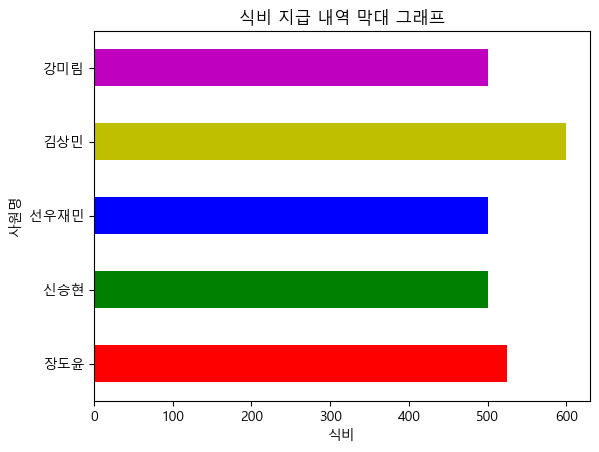

In [42]:
import matplotlib.pyplot as plt
plt.rc('font', family='Malgun Gothic')

chartdata01.plot(kind='barh', rot = 0, 
use_index=True, grid=False, table=False, color=['r', 'g', 'b', 'y', 'm'])
plt.xlabel('식비')
plt.ylabel('사원명')
plt.title('식비 지급 내역 막대 그래프')

<h4><font color="green">수평 막대 그래프(값 기반 오름차순 정렬)</font></h4>

In [43]:
chartdata02=payment['식비'].sort_values(ascending=True)
chartdata02.to_frame()

,식비
사원명,
강미림,500.0
신승현,500.0
선우재민,500.0
장도윤,525.0
김상민,600.0


Text(0.5, 1.0, '식비 지급 내역(값 기반 오름차순)')

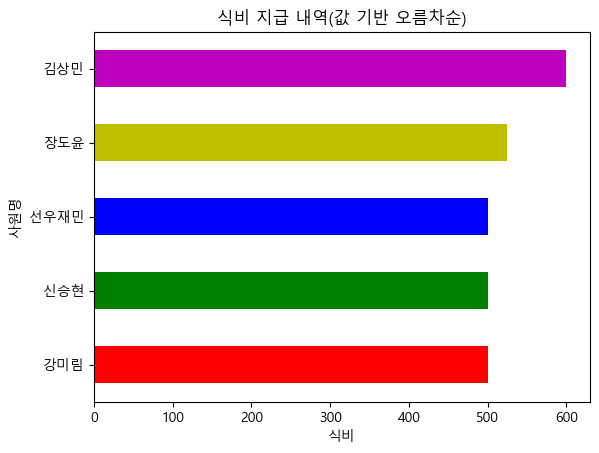

In [44]:
chartdata02.plot(kind='barh', rot = 0, 
use_index=True, grid=False, table=False, color=['r', 'g', 'b', 'y', 'm'])
plt.xlabel('식비')
plt.ylabel('사원명')
plt.title('식비 지급 내역(값 기반 오름차순)')

<h4><font color="green">수평 막대 그래프(값 기반 내림차순 정렬)</font></h4>

In [45]:
chartdata03=payment['식비'].sort_values(ascending=False)
chartdata03.to_frame()

,식비
사원명,
김상민,600.0
장도윤,525.0
강미림,500.0
신승현,500.0
선우재민,500.0


Text(0.5, 1.0, '식비 지급 내역(값 기반 내림차순)')

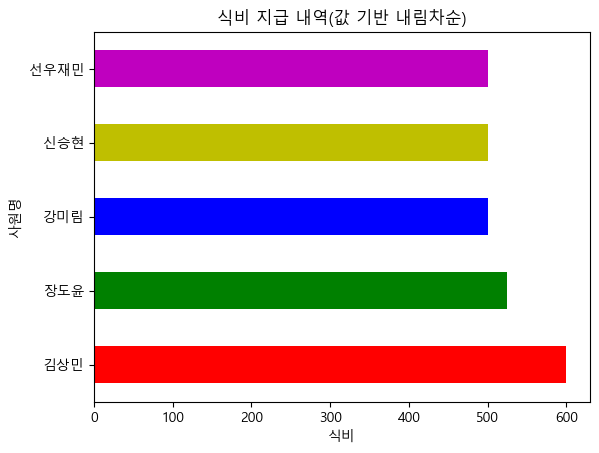

In [46]:
chartdata03.plot(kind='barh', rot = 0, 
use_index=True, grid=False, table=False, color=['r', 'g', 'b', 'y', 'm'])
plt.xlabel('식비')
plt.ylabel('사원명')
plt.title('식비 지급 내역(값 기반 내림차순)')